In [1]:
!pip install tensorflow pandas matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np

# Sample dataset
data = {
    'Hours_Study': [1,2,3,4,5,6,7,8,9,10],
    'Score': [15,20,28,35,50,55,65,75,85,95]
}

df = pd.DataFrame(data)

print(df)

   Hours_Study  Score
0            1     15
1            2     20
2            3     28
3            4     35
4            5     50
5            6     55
6            7     65
7            8     75
8            9     85
9           10     95


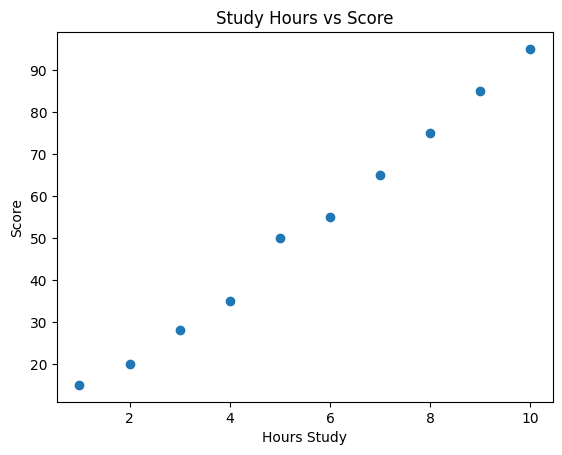

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df['Hours_Study'], df['Score'])
plt.xlabel("Hours Study")
plt.ylabel("Score")
plt.title("Study Hours vs Score")
plt.show()

In [4]:
X = df[['Hours_Study']]
y = df['Score']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train)

   Hours_Study
5            6
0            1
7            8
2            3
9           10
4            5
3            4
6            7


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [7]:
model = Sequential()

model.add(Dense(8, activation='relu', input_shape=(1,)))
model.add(Dense(4, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3255.5454 - mae: 51.6326
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 3253.7891 - mae: 51.6184
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 3251.9946 - mae: 51.6039
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3250.1606 - mae: 51.5890
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 3248.2886 - mae: 51.5739
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 3246.3767 - mae: 51.5584
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 3244.4253 - mae: 51.5426
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 3242.4336 - mae: 51.5265
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 3240.4023 - mae: 51.5101
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 3238.3303 - mae: 51.4933
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 3236.2173 - mae: 51.4762
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 3234.0637 - mae: 51.4588
Epoch 13/20
1

In [11]:
loss, mae = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("MAE:", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step - loss: 3683.3347 - mae: 51.5363
Loss: 3683.334716796875
MAE: 51.53631591796875


In [13]:
import numpy as np

prediction = model.predict(np.array([[7]]))

print("Predicted Score:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Predicted Score: 1.1556036


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


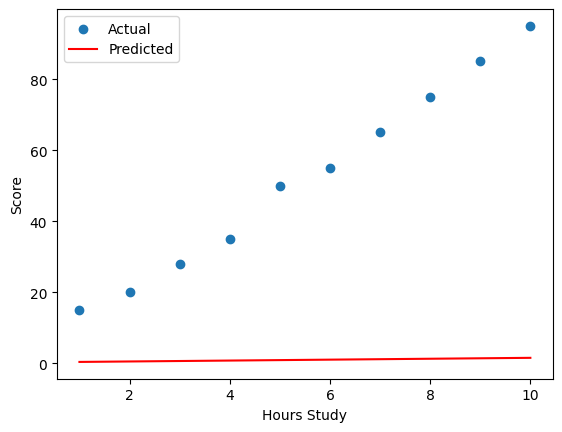

In [14]:
predictions = model.predict(X)

plt.scatter(X, y, label='Actual')
plt.plot(X, predictions, color='red', label='Predicted')

plt.xlabel("Hours Study")
plt.ylabel("Score")
plt.legend()

plt.show()

In [15]:
model.save("value_prediction_model.h5")

In [17]:
from google.colab import files

files.download("value_prediction_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>